## Сравнение Decision Tree и XGBoost на задаче классификации сетевого трафика IoT

**Гипотеза:** На хорошо разделимых данных (IoT-трафик N-BaIoT) простое дерево решений показывает сопоставимую точность с XGBoost, тогда как бустинг требует кратно больше вычислительного времени - что ставит под сомнение его целесообразность в подобных условиях.

---
## 1. Выбор датасета

### 1.1 Источник данных

**Датасет:** [N-BaIoT - Network-based detection of IoT Botnet attacks](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Формат:** CSV (набор файлов, разбитых по устройствам и типам трафика)

Датасет собран в лабораторных условиях: исследователи заразили реальные IoT-устройства (IP-камеры, роутеры) вредоносным ПО семейств **Mirai** и **BASHLITE**, после чего отслеживали сетевой трафик. Каждая строка - это набор характеристик TCP/UDP-потоков (длина пакетов, скорость, энтропия и тд), вычисленных за определённое временное окно.

### 1.2 Структура файлов

| Папка / файл | Тип трафика |
|---|---|
| `*.benign.csv` | Нормальный трафик |
| `mirai_attacks/1.scan.csv` | Сканирование портов (Mirai) |
| `mirai_attacks/2.syn.csv` | SYN-флуд |
| `mirai_attacks/3.ack.csv` | ACK-флуд |
| `mirai_attacks/4.udp.csv` | UDP-флуд |
| `mirai_attacks/5.udpplain.csv` | UDP Plain флуд |
| `gafgyt_attacks/1.tcp.csv` | TCP-флуд (BASHLITE) |
| `gafgyt_attacks/2.udp.csv` | UDP-флуд (BASHLITE) |
| `gafgyt_attacks/3.http.csv` | HTTP-флуд |
| `gafgyt_attacks/4.combo.csv` | Комбинированная атака |
| `gafgyt_attacks/5.scan.csv` | Сканирование (BASHLITE) |

### 1.3 Релевантность для задачи

Датасет подходит для двух задач классификации:
- **Бинарная:** `benign vs. attack` - нормальный трафик или атака?
- **Мультиклассовая:** определить конкретный тип атаки (11 классов)

In [133]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

SEED = 42

In [134]:
DATASET_ROOT = './data'

def load_nbaiot(root: str) -> pd.DataFrame:
    """Обходит все CSV-файлы в папке root, добавляет метки из пути к файлу."""
    records = []
    for fpath in sorted(glob.glob(os.path.join(root, '**', '*.csv'), recursive=True)):
        rel = os.path.relpath(fpath, root)
        parts = rel.replace('\\', '/').split('/')

        # Определяем метку мультикласса из имени файла
        fname = os.path.splitext(parts[-1])[0]
        if 'benign' in fname.lower():
            label = 'benign'
        elif len(parts) >= 2:
            attack_folder = parts[-2] if len(parts) > 1 else ''
            label = f"{attack_folder}__{fname}"
        else:
            label = fname

        try:
            tmp = pd.read_csv(fpath, low_memory=False)
            tmp['label'] = label
            records.append(tmp)
        except Exception as e:
            print(f'Пропущен файл {fpath}: {e}')

    df = pd.concat(records, ignore_index=True)
    
    # Бинарная метка
    df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'benign' else 1)
    return df

df = load_nbaiot(DATASET_ROOT)
print(f'Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} столбцов')

C:\Users\user\AppData\Local\Temp\ipykernel_8836\2558357401.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp['label'] = label


Датасет загружен: 151,743 строк, 117 столбцов


C:\Users\user\AppData\Local\Temp\ipykernel_8836\2558357401.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'benign' else 1)


### 1.4 Размерность датасета

In [135]:
n_rows, n_cols = df.shape
n_features = n_cols - 2 # вычитаем добавленные 'label' и 'binary_label'

print(f'Строк: {n_rows:>23,}')
print(f'Признаков: {n_features:>15}')
print(f'Классов (мульти): {df["label"].nunique():>6}')
print(f'Классов (бинарно): {df["binary_label"].nunique():>5}')
print(f'\nФормат данных: CSV, все признаки числовые (float64)')
print(f'Типы данных:')
print(df.dtypes.value_counts())

Строк:                 151,743
Признаков:             115
Классов (мульти):      2
Классов (бинарно):     2

Формат данных: CSV, все признаки числовые (float64)
Типы данных:
float64    115
str          1
int64        1
Name: count, dtype: int64


---
## 2. Предварительный анализ данных (EDA)

### 2.1 Основные статистики

In [136]:
feature_cols = [c for c in df.columns if c not in ('label', 'binary_label')]

stats = df[feature_cols].describe().T
stats['median'] = df[feature_cols].median()
stats = stats[['count', 'mean', 'median', 'std', 'min', 'max']]
stats.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max']

print('Статистики по первым 10 признакам:')
stats.head(10)

Статистики по первым 10 признакам:


,Count,Mean,Median,Std,Min,Max
MI_dir_L5_weight,151743.0000,90.0787,107.9923,65.1904,1.0000,199.4077
MI_dir_L5_mean,151743.0000,287.9759,292.5880,160.3104,60.0000,566.0000
MI_dir_L5_variance,151743.0000,32780.8532,37042.7405,26221.5957,0.0000,64009.0000
MI_dir_L3_weight,151743.0000,145.7822,190.3875,102.8150,1.0000,288.8724
MI_dir_L3_mean,151743.0000,289.5368,327.4667,148.4512,60.0000,566.0000
MI_dir_L3_variance,151743.0000,36518.4716,46827.3853,26795.5291,0.0000,64009.0000
MI_dir_L1_weight,151743.0000,428.1071,609.6516,297.6391,1.0000,720.4002
MI_dir_L1_mean,151743.0000,292.2220,368.9209,140.5324,60.0000,566.0000
MI_dir_L1_variance,151743.0000,38857.6432,54812.1076,27182.8131,0.0000,63717.8406
MI_dir_L0.1_weight,151743.0000,4216.5690,6262.5375,2937.2543,1.0000,6466.7720


In [137]:
print('Сводка по диапазонам значений:')
print(f'Признаков с Max > 1e6: {(stats["Max"] > 1e6).sum()}')
print(f'Признаков с нулевым Std: {(stats["Std"] == 0).sum()} (постоянные - кандидаты на удаление)')
print(f'Признаков с Min < 0: {(stats["Min"] < 0).sum()}')

Сводка по диапазонам значений:
Признаков с Max > 1e6: 10
Признаков с нулевым Std: 0 (постоянные - кандидаты на удаление)
Признаков с Min < 0: 20


### 2.2 Распределение целевой переменной

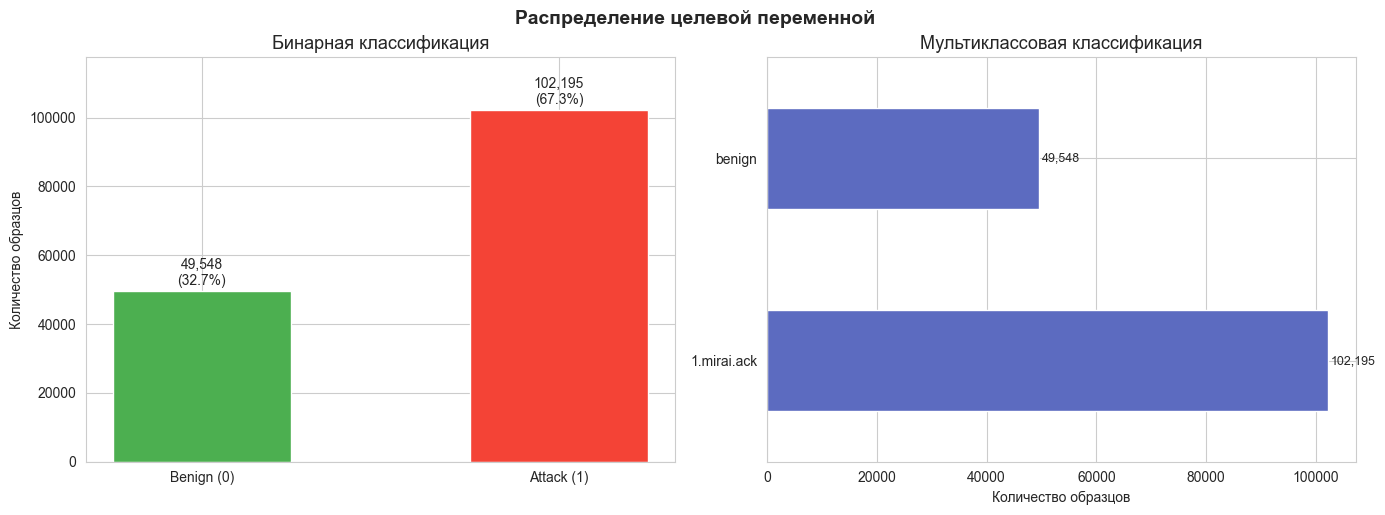

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Бинарная
bin_counts = df['binary_label'].value_counts().sort_index()
labels_bin = ['Benign (0)', 'Attack (1)']
colors_bin = ['#4CAF50', '#F44336']
axes[0].bar(labels_bin, bin_counts.values, color=colors_bin, edgecolor='white', width=0.5)
for i, v in enumerate(bin_counts.values):
    axes[0].text(i, v + max(bin_counts.values)*0.01, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Бинарная классификация', fontsize=13)
axes[0].set_ylabel('Количество образцов')
axes[0].set_ylim(0, max(bin_counts.values) * 1.15)

# Мультиклассовая
multi_counts = df['label'].value_counts()
multi_counts.plot(kind='barh', ax=axes[1], color='#5C6BC0', edgecolor='white')
axes[1].set_title('Мультиклассовая классификация', fontsize=13)
axes[1].set_xlabel('Количество образцов')
axes[1].set_ylabel('')
for i, v in enumerate(multi_counts.values):
    axes[1].text(v + max(multi_counts.values)*0.005, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Распределение целевой переменной', fontsize=14, y=1.02, fontweight='bold')
plt.show()

### 2.3 Визуализация ключевых признаков

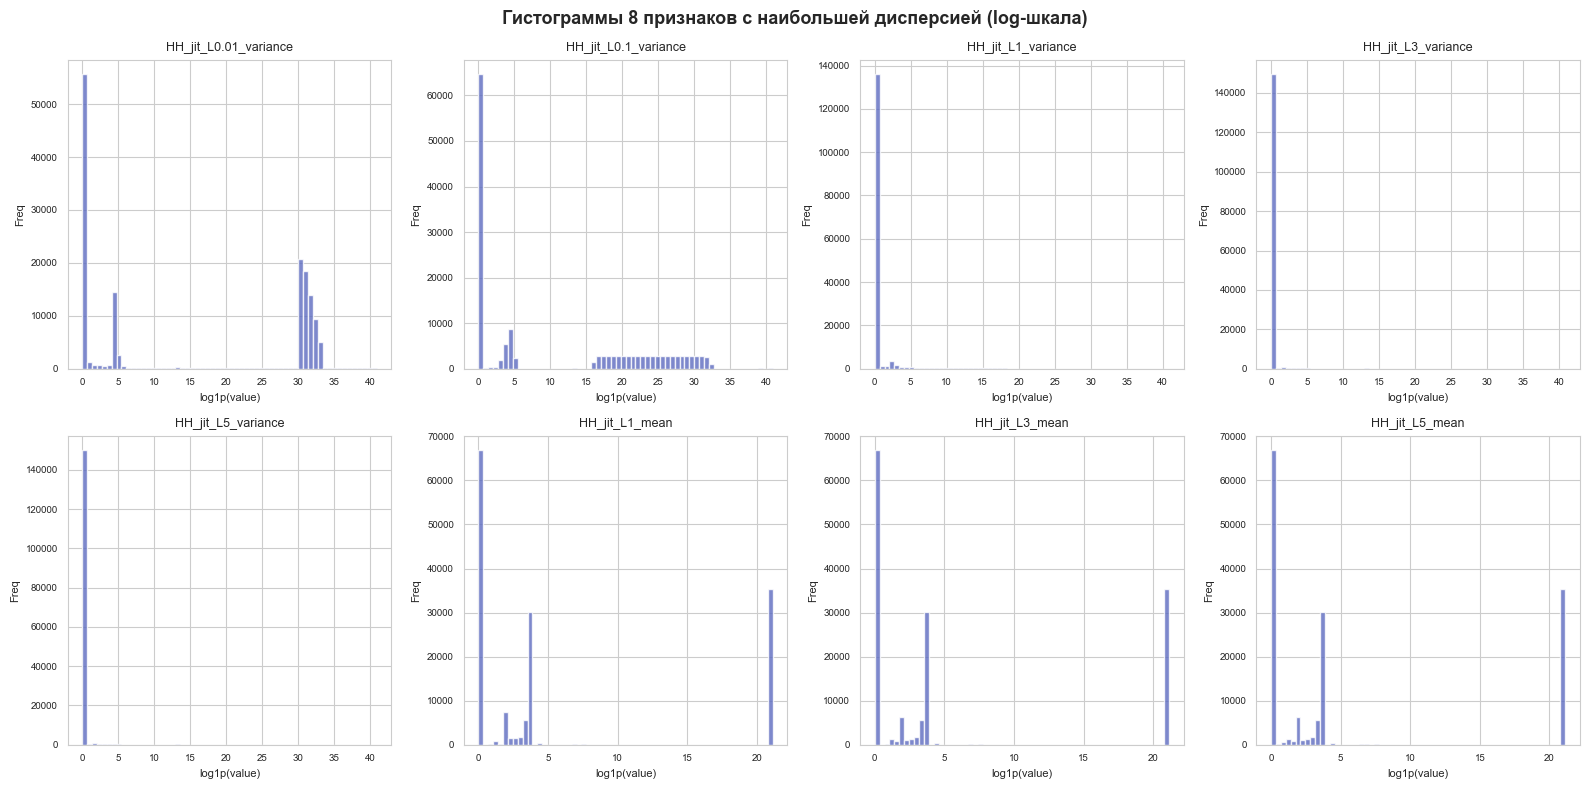

In [139]:
# Выбираем признаки с наибольшей дисперсией для визуализации
top_features = df[feature_cols].std().nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    # log1p для наглядности при больших диапазонах
    vals = np.log1p(df[feat].clip(lower=0))
    axes[i].hist(vals, bins=60, color='#5C6BC0', alpha=0.8, edgecolor='white')
    axes[i].set_title(feat[:30], fontsize=9)
    axes[i].set_xlabel('log1p(value)', fontsize=8)
    axes[i].set_ylabel('Freq', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Гистограммы 8 признаков с наибольшей дисперсией (log-шкала)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Выявление проблем в данных

In [ ]:
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('Пропущенные значения:')
if missing.sum() == 0:
    print('Пропущенных значений не обнаружено')
else:
    miss_df = pd.DataFrame({'Missing': missing, 'Missing%': missing_pct})
    print(miss_df[miss_df['Missing'] > 0].sort_values('Missing%', ascending=False))

Пропущенные значения
Пропущенных значений не обнаружено


In [141]:
print('Оценка выбросов (IQR-метод)')

outlier_counts = {}
for feat in feature_cols:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)).sum()
    outlier_counts[feat] = n_out

out_series = pd.Series(outlier_counts).sort_values(ascending=False)
print(f'Признаков с выбросами (>0): {(out_series > 0).sum()} из {len(feature_cols)}')
print('\nТоп-10 признаков по количеству выбросов:')
print(out_series.head(10).to_string())

print('\nНо учитывая контекст датасета, выбросы не удаляем. Так как в сетевом трафике выбросы часто несут значимую информацию')

Оценка выбросов (IQR-метод)
Признаков с выбросами (>0): 55 из 115

Топ-10 признаков по количеству выбросов:
HH_L0.01_covariance      49318
HH_L0.1_covariance       49255
HpHp_L0.01_covariance    48688
HpHp_L0.1_covariance     48600
HH_L1_covariance         45651
HpHp_L1_covariance       44331
HH_L0.01_pcc             38169
HH_jit_L0.01_mean        36972
HH_L1_radius             36215
HH_jit_L1_mean           35834

Но учитывая контекст датасета, выбросы не удаляем. Так как в сетевом трафике выбросы часто несут значимую информацию


In [142]:
print('Дисбаланс классов (бинарная задача)')
bin_dist = df['binary_label'].value_counts(normalize=True) * 100
print(f'Benign (0): {bin_dist.get(0, 0):.1f}%')
print(f'Attack (1): {bin_dist.get(1, 0):.1f}%')

ratio = bin_dist.max() / bin_dist.min() if bin_dist.min() > 0 else float('inf')
print(f'Соотношение мажоритарный:миноритарный = {ratio:.1f}:1')

if ratio > 5:
    print('Значительный дисбаланс, нужна балансировка')
elif ratio > 2:
    print('Умеренный дисбаланс, балансировка на усмотрение')
else:
    print('Классы сбалансированы, специальных мер не требуется')

print('\nДисбаланс классов (мультиклассовая задача)')
mc_dist = df['label'].value_counts(normalize=True) * 100
print(mc_dist.round(2).to_string())

Дисбаланс классов (бинарная задача)
Benign (0): 32.7%
Attack (1): 67.3%
Соотношение мажоритарный:миноритарный = 2.1:1
Умеренный дисбаланс, балансировка на усмотрение

Дисбаланс классов (мультиклассовая задача)
label
1.mirai.ack   67.3500
benign        32.6500


### 2.5 Корреляция признаков с целевой переменной

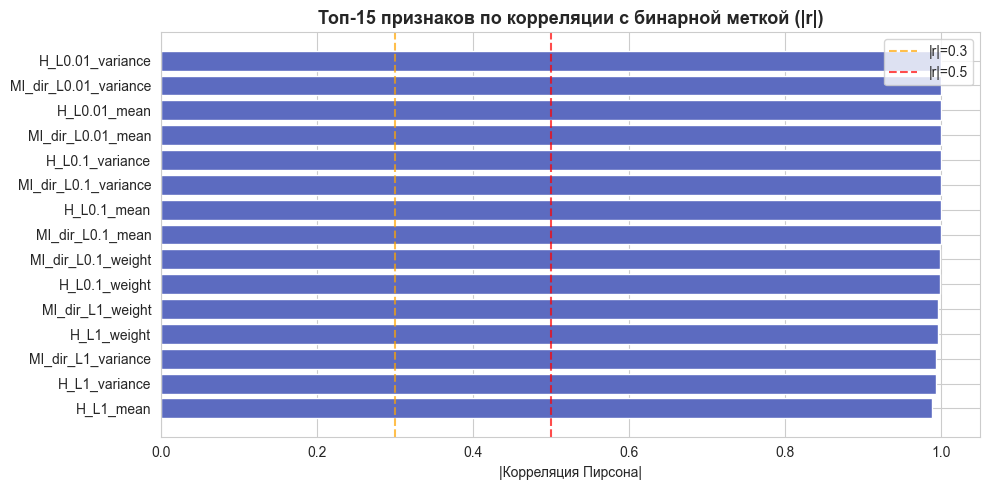

Признаков с |r| > 0.5: 61
Признаков с |r| > 0.3: 70


In [143]:
corr_with_target = df[feature_cols].corrwith(df['binary_label']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top_corr = corr_with_target.head(15)
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color='#5C6BC0', edgecolor='white')
ax.set_title('Топ-15 признаков по корреляции с бинарной меткой (|r|)', fontsize=13, fontweight='bold')
ax.set_xlabel('|Корреляция Пирсона|')
ax.axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='|r|=0.3')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='|r|=0.5')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Признаков с |r| > 0.5: {(corr_with_target > 0.5).sum()}')
print(f'Признаков с |r| > 0.3: {(corr_with_target > 0.3).sum()}')

## 3. Предобработка данных

### 3.1 Обработка пропущенных значений

По результатам анализа датасет не содержит пропущенных значений

### 3.2 Масштабирование данных

Выбранные алгоритмы (деревья) не требуют масштабирования для качества предсказания, но поскольку в датасете много выбросов, то **RobustScaler** не помешает. Применяется для корректного сравнения и совместимости с будущими экспериментами.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder

X = df[feature_cols].copy()
y_binary = df['binary_label'].copy()
y_multi = df['label'].copy()

# Удаляем постоянные признаки (std == 0)
constant_cols = [c for c in feature_cols if X[c].std() == 0]
print(f'Постоянных признаков (std=0): {len(constant_cols)}')
if constant_cols:
    X.drop(columns=constant_cols, inplace=True)
    print('Удалены:', constant_cols[:10], '...' if len(constant_cols) > 10 else '')

# Масштабирование
scaler   = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

# Кодирование мультиклассовой метки
le          = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print('\nКлассы (мультиклассовая задача):')
for i, cls in enumerate(le.classes_):
    print(f'{i:2d} - {cls}')

Постоянных признаков (std=0): 0

Классы (мультиклассовая задача):
   0 → 1.mirai.ack
   1 → benign


### 3.3 Категориальные признаки

Категориальных признаков нет.

### 3.4 Снижение размерности

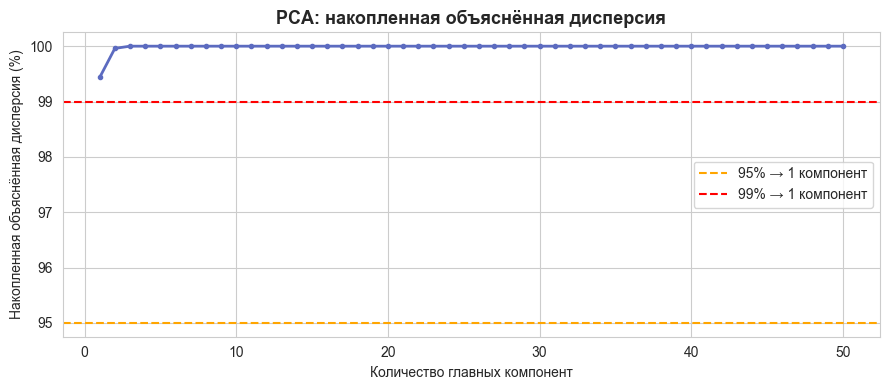

95% дисперсии → 1 компонент (из 115)
99% дисперсии → 1 компонент

→ Для базового сравнения используем все признаки без PCA.
  PCA применим как опцию в случае нехватки ресурсов или переобучения.


In [ ]:
from sklearn.decomposition import PCA

# PCA для оценки информативности признаков
pca_exp = PCA(n_components=min(50, X_scaled.shape[1]), random_state=SEED)
pca_exp.fit(X_scaled)

cumvar = np.cumsum(pca_exp.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
n99 = np.argmax(cumvar >= 0.99) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar * 100, marker='.', color='#5C6BC0', linewidth=2)
ax.axhline(95, color='orange', linestyle='--', label=f'95% - {n95} компонент')
ax.axhline(99, color='red', linestyle='--', label=f'99% - {n99} компонент')
ax.set_xlabel('Количество главных компонент')
ax.set_ylabel('Накопленная объяснённая дисперсия (%)')
ax.set_title('PCA: накопленная объяснённая дисперсия', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'95% дисперсии - {n95} компонент (из {X_scaled.shape[1]})')
print(f'99% дисперсии - {n99} компонент')

## 4. Выбор алгоритмов и метрик оценки

### 4.1 Обоснование выбора алгоритмов

#### Decision Tree (одиночное дерево решений)

- **Интерпретируемость:** легко визуализировать и объяснить, почему трафик классифицирован как атака
- **Скорость:** обучение и инференс на CPU существенно быстрее ансамблевых методов
- **Базовый алгоритм:** хорошая точка отсчёта для оценки того, что привносит бустинг

#### XGBoost (gradient boosting)

- **Итеративное исправление ошибок:** последовательно строит деревья, корректируя остатки предыдущих
- **Регуляризация:** встроенные L1/L2-штрафы снижают переобучение

#### Почему оба алгоритма запускаются на CPU

1. **Честность сравнения:** GPU-ускоренный XGBoost (CUDA) против CPU-дерева был бы некорректным сопоставлением
2. **Доступность:** не всегда есть возможность запуска на GPU
3. **Реалистичность:** обучение на GPU стоит дороже

### 4.2 Метрики оценки

| Метрика | Обоснование |
|---|---|
| **Accuracy** | Общая доля правильных ответов |
| **Precision** | Сколько из "атак" реально атаки (ложные тревоги) |
| **Recall** | Сколько реальных атак обнаружено (пропущенные угрозы) |
| **F1-score** | Баланс Precision/Recall |
| **Время обучения** | **Ключевая метрика для поставленной гипотезы** |

### 4.3 Борьба с переобучением

| Метод | Decision Tree | XGBoost |
|---|---|---|
| Ограничение глубины (`max_depth`) | + | + |
| Минимальное количество образцов в листе (`min_samples_leaf`) | + | + |
| L1/L2-регуляризация | - | + |
| Ранняя остановка | - | + |


---
## 5. Инструментарий для улучшения качества данных

### 5.1 Аугментация данных

Не требуется

### 5.2 Балансировка классов

In [146]:
# Оценка необходимости балансировки
bin_ratio = y_binary.value_counts(normalize=True)
imbalance_ratio = bin_ratio.max() / bin_ratio.min()

print(f'Соотношение классов (бинарная): {imbalance_ratio:.1f}:1')
print()

print('Способы борьбы с дисбалансом:')
print('class_weight="balanced" в DecisionTreeClassifier')
print('scale_pos_weight = N_negative / N_positive в XGBoost')

Соотношение классов (бинарная): 2.1:1

Способы борьбы с дисбалансом:
class_weight="balanced" в DecisionTreeClassifier
scale_pos_weight = N_negative / N_positive в XGBoost
